**PCA Analysis - Group Separability**

Before training a CNN, we visualize the data in lower-dimensional space using Principal Component Analysis (PCA) to understand group structure and separability.

**Key observations:**

- High-dimensional problem: 229 PCs needed to explain 95% of variance, indicating that discriminative information is spread across many dimensions
- Low linear separability: Groups are heavily overlapped in 2D/3D PCA space (only 9.4% variance explained by PC1+PC2), suggesting linear methods (RF, SVM) will struggle
- Justifies CNN approach: The complex, non-linear patterns in the data make a convolutional neural network well-suited for this classification task
- The overlapping groups indicate that subtle differences in NMR peak patterns—rather than obvious structural differences—distinguish the compound classes. A CNN can learn these non-linear boundaries better than simpler classifiers.


Data shape: (847, 400)
Number of groups: 5
Groups: ['Aromatics' 'Heterocycles & nucleotides' 'Lipids'
 'Nitrogenous & organic acids' 'Organic oxygen compounds']

Feature scaling complete. Mean: 0.000000, Std: 0.957862

Variance explained by first 10 PCs: 0.2222
Components needed for 95% variance: 229

2D PCA variance explained: 0.0940
3D PCA variance explained: 0.1205

✓ Saved: pca_visualization.png


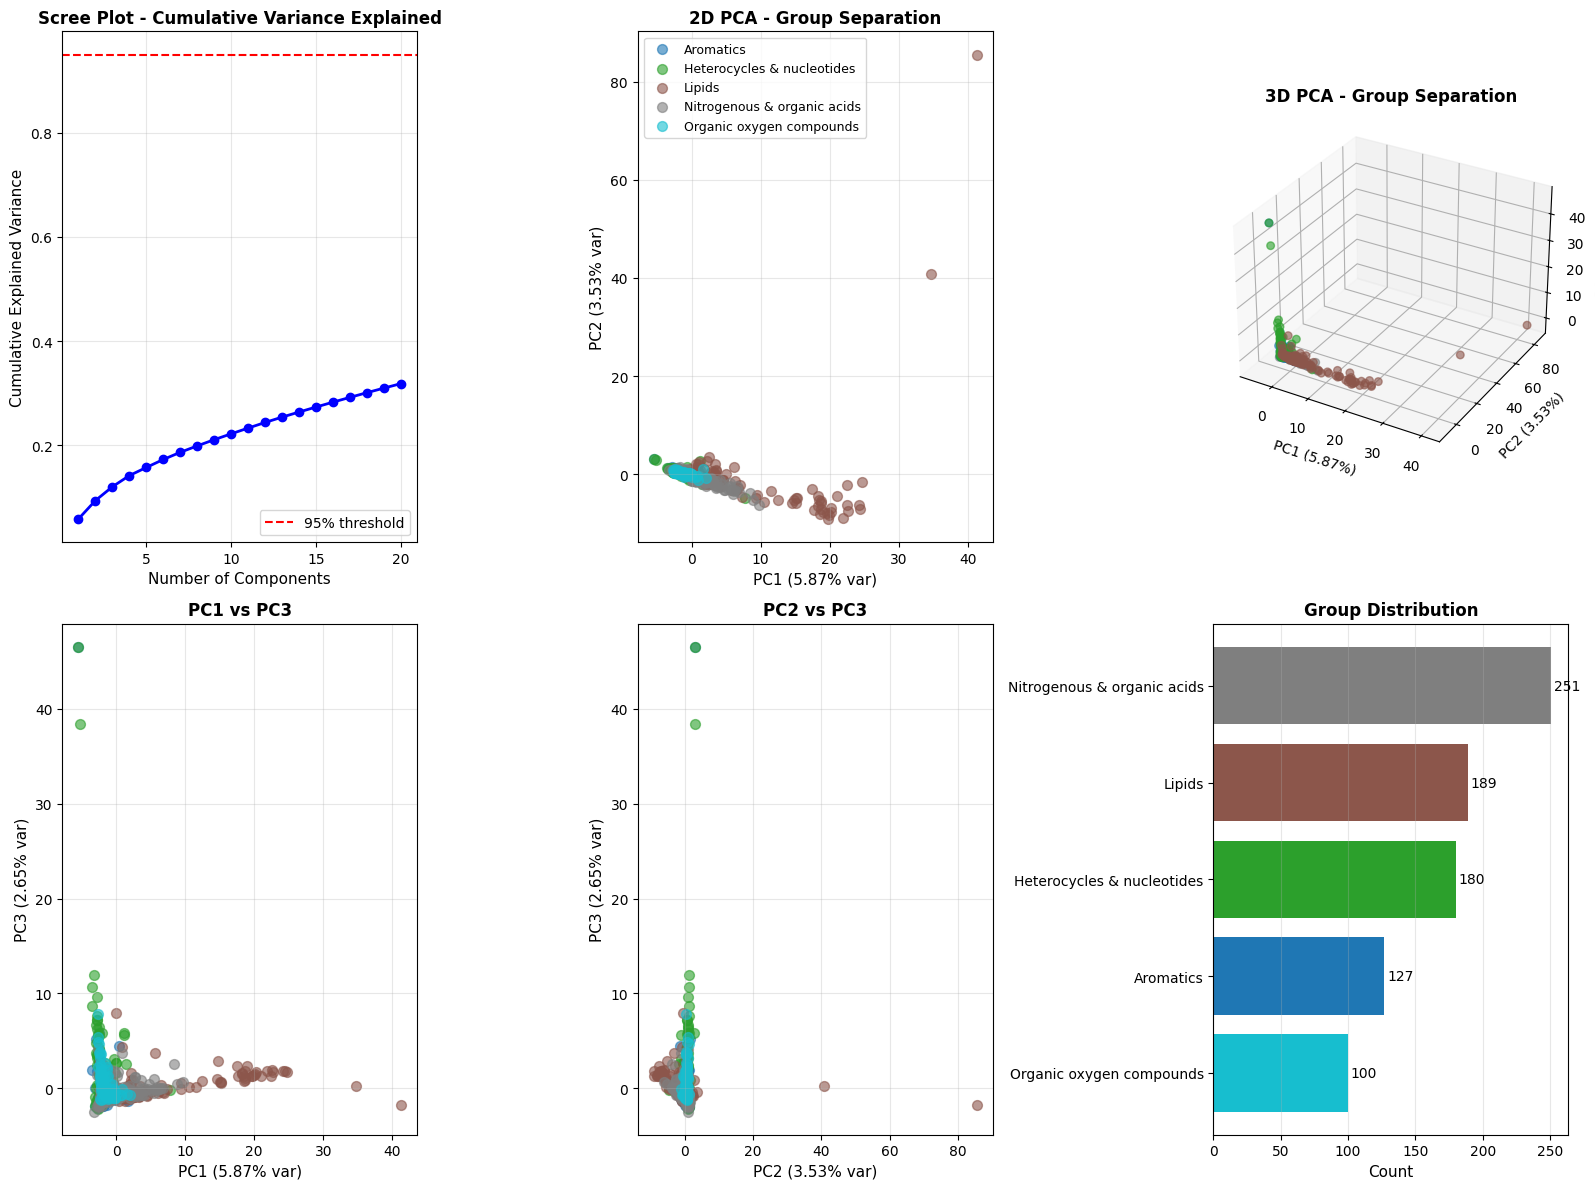


PCA ANALYSIS SUMMARY
First 3 PCs explain: 12.05% of variance
First 10 PCs explain: 22.22% of variance
First 229 PCs explain: 95% of variance

Per-group statistics:
  Aromatics.......................... 127 ( 15.0%)
  Heterocycles & nucleotides......... 180 ( 21.3%)
  Lipids............................. 189 ( 22.3%)
  Nitrogenous & organic acids........ 251 ( 29.6%)
  Organic oxygen compounds........... 100 ( 11.8%)

INTERPRETATION:
• If groups cluster tightly → CNN likely unnecessary (RF/SVM will work)
• If groups overlap significantly → CNN might learn better patterns
• If no clear structure → Consider data quality or feature engineering


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- LOAD DATA ---
df = pd.read_csv("processed_data/nmr_features_with_groups.csv")

# Separate features and labels
X = df.iloc[:, 2:].values  # All bin columns (skip accession and group)
y = df['group'].values
groups_unique = np.unique(y)

print(f"Data shape: {X.shape}")
print(f"Number of groups: {len(groups_unique)}")
print(f"Groups: {groups_unique}")

# --- STANDARDIZE FEATURES ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeature scaling complete. Mean: {X_scaled.mean():.6f}, Std: {X_scaled.std():.6f}")

# --- PCA ANALYSIS ---
# First, fit full PCA to see cumulative variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Find how many components explain 95% of variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f"\nVariance explained by first 10 PCs: {cumsum_var[9]:.4f}")
print(f"Components needed for 95% variance: {n_components_95}")

# Fit PCA with 2 and 3 components for visualization
pca_2d = PCA(n_components=2)
pca_3d = PCA(n_components=3)

X_pca_2d = pca_2d.fit_transform(X_scaled)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\n2D PCA variance explained: {pca_2d.explained_variance_ratio_.sum():.4f}")
print(f"3D PCA variance explained: {pca_3d.explained_variance_ratio_.sum():.4f}")

# --- PLOTTING ---
fig = plt.figure(figsize=(16, 12))

# Define colors for groups
colors = plt.cm.tab10(np.linspace(0, 1, len(groups_unique)))
group_colors = {group: colors[i] for i, group in enumerate(groups_unique)}

# 1. Scree plot (variance explained)
ax1 = plt.subplot(2, 3, 1)
ax1.plot(range(1, 21), cumsum_var[:20], 'bo-', linewidth=2, markersize=6)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax1.set_xlabel('Number of Components', fontsize=11)
ax1.set_ylabel('Cumulative Explained Variance', fontsize=11)
ax1.set_title('Scree Plot - Cumulative Variance Explained', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. 2D PCA scatter plot
ax2 = plt.subplot(2, 3, 2)
for group in groups_unique:
    mask = y == group
    ax2.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               label=group, alpha=0.6, s=50, color=group_colors[group])
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} var)', fontsize=11)
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} var)', fontsize=11)
ax2.set_title('2D PCA - Group Separation', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)

# 3. 3D PCA scatter plot
ax3 = plt.subplot(2, 3, 3, projection='3d')
for group in groups_unique:
    mask = y == group
    ax3.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               label=group, alpha=0.6, s=30, color=group_colors[group])
ax3.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})', fontsize=10)
ax3.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})', fontsize=10)
ax3.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})', fontsize=10)
ax3.set_title('3D PCA - Group Separation', fontsize=12, fontweight='bold')

# 4. PC1 vs PC3
ax4 = plt.subplot(2, 3, 4)
for group in groups_unique:
    mask = y == group
    ax4.scatter(X_pca_2d[mask, 0], X_pca_3d[mask, 2],
               label=group, alpha=0.6, s=50, color=group_colors[group])
ax4.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} var)', fontsize=11)
ax4.set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%} var)', fontsize=11)
ax4.set_title('PC1 vs PC3', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. PC2 vs PC3
ax5 = plt.subplot(2, 3, 5)
for group in groups_unique:
    mask = y == group
    ax5.scatter(X_pca_2d[mask, 1], X_pca_3d[mask, 2],
               label=group, alpha=0.6, s=50, color=group_colors[group])
ax5.set_xlabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} var)', fontsize=11)
ax5.set_ylabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%} var)', fontsize=11)
ax5.set_title('PC2 vs PC3', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Group size distribution
ax6 = plt.subplot(2, 3, 6)
group_counts = pd.Series(y).value_counts().sort_values(ascending=True)
ax6.barh(range(len(group_counts)), group_counts.values, 
         color=[group_colors[g] for g in group_counts.index])
ax6.set_yticks(range(len(group_counts)))
ax6.set_yticklabels(group_counts.index, fontsize=10)
ax6.set_xlabel('Count', fontsize=11)
ax6.set_title('Group Distribution', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(group_counts.values):
    ax6.text(v + 2, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('CNN_attempt_figures/pca_visualization.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pca_visualization.png")
plt.show()

# --- SUMMARY STATISTICS ---
print("\n" + "="*60)
print("PCA ANALYSIS SUMMARY")
print("="*60)
print(f"First 3 PCs explain: {pca_3d.explained_variance_ratio_.sum():.2%} of variance")
print(f"First 10 PCs explain: {cumsum_var[9]:.2%} of variance")
print(f"First {n_components_95} PCs explain: 95% of variance")
print("\nPer-group statistics:")
for group in groups_unique:
    count = (y == group).sum()
    pct = 100 * count / len(y)
    print(f"  {group:.<35} {count:>3} ({pct:>5.1f}%)")
print("="*60)

# --- INTERPRETATION GUIDE ---
print("\nINTERPRETATION:")
print("• If groups cluster tightly → CNN likely unnecessary (RF/SVM will work)")
print("• If groups overlap significantly → CNN might learn better patterns")
print("• If no clear structure → Consider data quality or feature engineering")

**CNN Training - Initial Attempt**

This section implements a 1D Convolutional Neural Network to classify H-NMR spectra into compound groups, with Random Forest as a baseline comparison.
Model Architecture

- Input: 400 binned spectral features (0-10 ppm range, 0.025 ppm/bin resolution)
- Architecture: 3 convolutional blocks (32→64→128 filters, kernel size 5) with batch normalization, max pooling, and dropout (0.3-0.4)
- Classifier: Global average pooling → Dense layers (256→128) → Softmax output (5 classes)
- Training: 100 epochs max, early stopping (patience=15), learning rate reduction, class weighting for imbalance

**Data Split**

- Train: 592 samples (69.9%)
- Validation: 127 samples (15.0%)
- Test: 128 samples (15.1%)
- Stratified splitting preserves group distribution

**Results**

CNN improvement over RF: -0.4922 (-49.22%)

**Analysis**

- The CNN significantly underperformed compared to Random Forest:
- Severe overfitting: Training accuracy reached ~42% while validation plateaued at ~24%, with validation loss exploding to >9000
- Poor generalization: Test accuracy of 15.6% is barely above random chance (20% for 5 classes)
- Prediction collapse: Confusion matrix shows the CNN defaulting to predicting predominantly one class ("Organic oxygen compounds")
- RF success: Random Forest achieved 64.8% test accuracy, demonstrating the features are informative but better suited to ensemble methods

**Conclusion**

This CNN architecture is too complex for the dataset size (847 samples) and fails to learn meaningful spectral patterns. The Random Forest baseline substantially outperforms the deep learning approach, suggesting either: (1) the problem is better suited to traditional ML methods, (2) a simpler CNN architecture is needed, or (3) data augmentation strategies should be explored.

**NOTE** - Gives different results each run. Document for report.

Data shape: (847, 400)
Classes: ['Aromatics' 'Heterocycles & nucleotides' 'Lipids'
 'Nitrogenous & organic acids' 'Organic oxygen compounds']
Number of classes: 5
Class encoding: {'Aromatics': 0, 'Heterocycles & nucleotides': 1, 'Lipids': 2, 'Nitrogenous & organic acids': 3, 'Organic oxygen compounds': 4}

Train set: 592 samples (69.9%)
Val set:   127 samples (15.0%)
Test set:  128 samples (15.1%)

Normalization complete. Train mean: 0.000000, std: 0.947365
CNN input shape: (592, 400, 1)


/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-16 14:27:36.789832: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-10-16 14:27:36.789861: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-10-16 14:27:36.789868: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-10-16 14:27:36.789886: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-16 14:27:36.789900: I tensorflow/core/common_runtime/pluggable_device

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 400, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 400, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 200, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 200, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 100, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,581 (471.02 KB)

...


Class weights: {0: 1.3303370786516855, 1: 0.9396825396825397, 2: 0.896969696969697, 3: 0.6765714285714286, 4: 1.6914285714285715}

TRAINING CNN
Epoch 1/100


2025-10-16 14:27:38.445657: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.2449 - loss: 2.1845 - val_accuracy: 0.2205 - val_loss: 2144.7200 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.2736 - loss: 2.0576 - val_accuracy: 0.2047 - val_loss: 7247.9390 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3345 - loss: 1.8347 - val_accuracy: 0.1654 - val_loss: 15289.0391 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3463 - loss: 1.7580 - val_accuracy: 0.2283 - val_loss: 1788.5702 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3311 - loss: 1.7749 - val_accuracy: 0.1575 - val_loss: 12802.2373 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3311 - loss: 1.7321 - val_accuracy: 0.2283 - val_loss: 4778.6631 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3564 - loss: 1

/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh


Random Forest Accuracy:
  Train: 0.9139
  Val:   0.5354
  Test:  0.6484

Improvement (CNN vs RF):
  Test accuracy improvement: -0.4141 (-41.41%)

✓ Saved: cnn_training_results.png


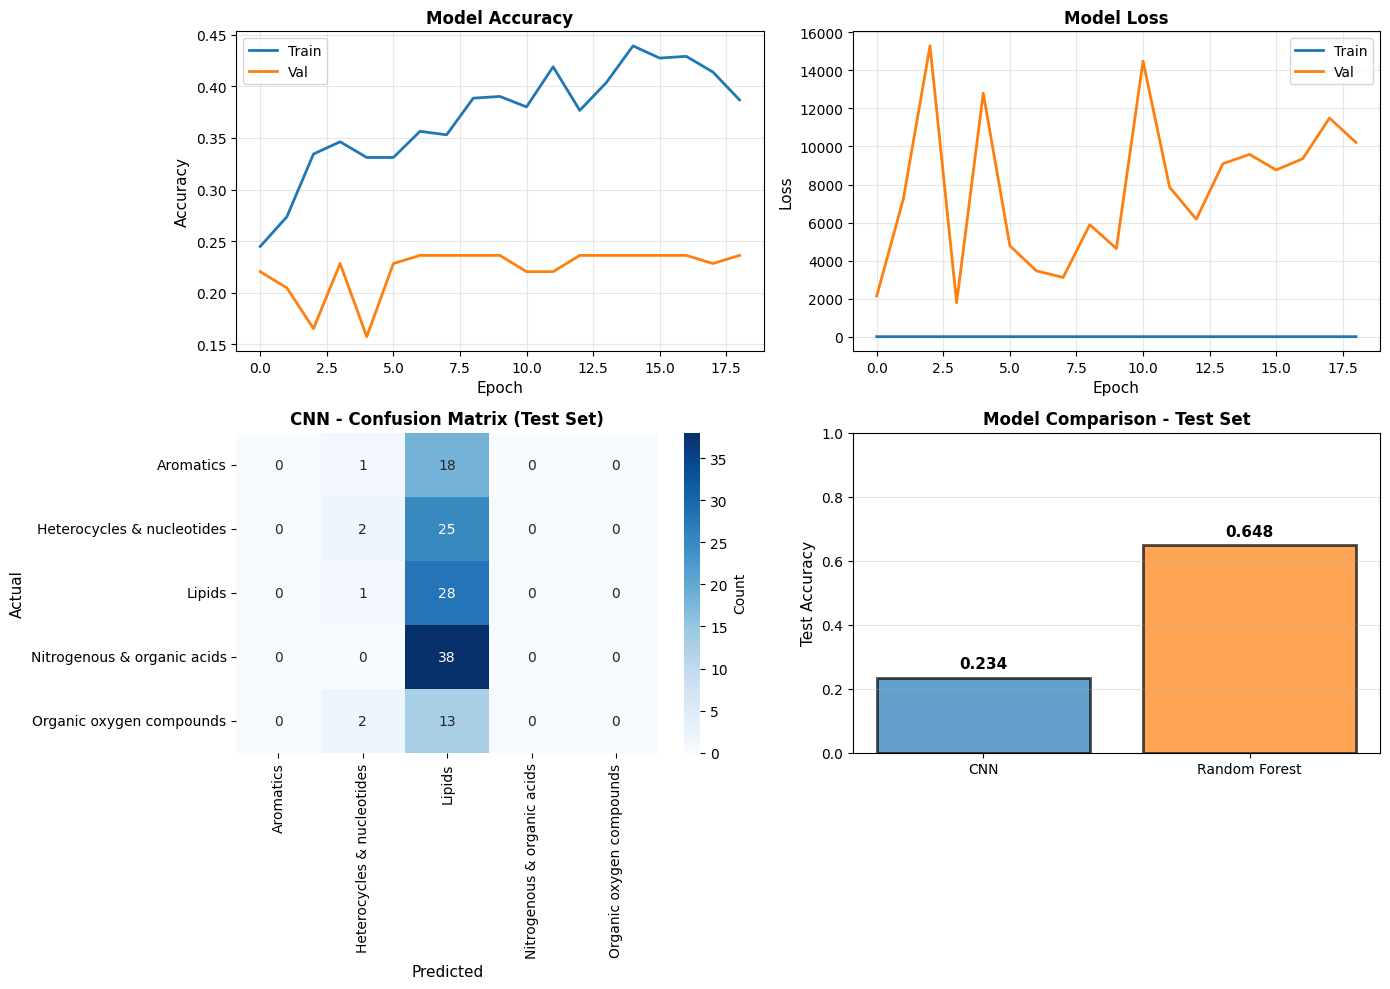

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns

# --- LOAD DATA ---
df = pd.read_csv("processed_data/nmr_features_with_groups.csv")

X = df.iloc[:, 2:].values  # All bin columns
y = df['group'].values

print(f"Data shape: {X.shape}")
print(f"Classes: {np.unique(y)}")

# --- ENCODE LABELS ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(le.classes_)

print(f"Number of classes: {n_classes}")
print(f"Class encoding: {dict(zip(le.classes_, range(n_classes)))}")

# --- STRATIFIED TRAIN/VAL/TEST SPLIT ---
# First split: 70% train, 30% temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

# Second split: split temp into 50/50 (15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain set: {X_train.shape[0]} samples ({100*X_train.shape[0]/len(X):.1f}%)")
print(f"Val set:   {X_val.shape[0]} samples ({100*X_val.shape[0]/len(X):.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({100*X_test.shape[0]/len(X):.1f}%)")

# --- NORMALIZE DATA (Z-score) ---
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8  # Add small epsilon to avoid division by zero
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_norm = (X_test - mean) / std

print(f"\nNormalization complete. Train mean: {X_train_norm.mean():.6f}, std: {X_train_norm.std():.6f}")

# --- RESHAPE FOR CNN (add channel dimension) ---
# CNN expects: (samples, timesteps, channels)
X_train_cnn = X_train_norm.reshape(-1, X_train_norm.shape[1], 1)
X_val_cnn = X_val_norm.reshape(-1, X_val_norm.shape[1], 1)
X_test_cnn = X_test_norm.reshape(-1, X_test_norm.shape[1], 1)

print(f"CNN input shape: {X_train_cnn.shape}")

# --- BUILD 1D CNN MODEL ---
model = keras.Sequential([
    # Block 1
    layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same',
                  input_shape=(X_train_cnn.shape[1], 1)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),
    
    # Block 2
    layers.Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),
    
    # Block 3
    layers.Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),
    
    # Global pooling
    layers.GlobalAveragePooling1D(),
    
    # Dense layers
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    # Output layer
    layers.Dense(n_classes, activation='softmax')
])

model.summary()

# --- COMPILE MODEL ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- CALCULATE CLASS WEIGHTS ---
# Handle class imbalance
unique, counts = np.unique(y_train, return_counts=True)
class_weights = {u: len(y_train) / (len(unique) * c) for u, c in zip(unique, counts)}
print(f"\nClass weights: {class_weights}")

# --- TRAIN MODEL ---
print("\n" + "="*60)
print("TRAINING CNN")
print("="*60)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)

# --- EVALUATE ON TEST SET ---
print("\n" + "="*60)
print("EVALUATION")
print("="*60)

y_train_pred = np.argmax(model.predict(X_train_cnn, verbose=0), axis=1)
y_val_pred = np.argmax(model.predict(X_val_cnn, verbose=0), axis=1)
y_test_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nAccuracy:")
print(f"  Train: {train_acc:.4f}")
print(f"  Val:   {val_acc:.4f}")
print(f"  Test:  {test_acc:.4f}")

print(f"\nF1-Score (weighted):")
print(f"  Train: {f1_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"  Val:   {f1_score(y_val, y_val_pred, average='weighted'):.4f}")
print(f"  Test:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# --- BASELINE: RANDOM FOREST ---
print("\n" + "="*60)
print("BASELINE: RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_norm, y_train)

rf_train_acc = rf.score(X_train_norm, y_train)
rf_val_acc = rf.score(X_val_norm, y_val)
rf_test_acc = rf.score(X_test_norm, y_test)

print(f"\nRandom Forest Accuracy:")
print(f"  Train: {rf_train_acc:.4f}")
print(f"  Val:   {rf_val_acc:.4f}")
print(f"  Test:  {rf_test_acc:.4f}")

print(f"\nImprovement (CNN vs RF):")
print(f"  Test accuracy improvement: {(test_acc - rf_test_acc):.4f} ({100*(test_acc - rf_test_acc):.2f}%)")

# --- PLOTTING ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training history - accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Training history - loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_,
            yticklabels=le.classes_, ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_xlabel('Predicted', fontsize=11)
axes[1, 0].set_ylabel('Actual', fontsize=11)
axes[1, 0].set_title('CNN - Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')

# Model comparison
models = ['CNN', 'Random Forest']
test_accuracies = [test_acc, rf_test_acc]
colors = ['#1f77b4', '#ff7f0e']
bars = axes[1, 1].bar(models, test_accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Test Accuracy', fontsize=11)
axes[1, 1].set_title('Model Comparison - Test Set', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, test_accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('CNN_attempt_figures/cnn_training_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: cnn_training_results.png")
plt.show()

print("="*60)

**Simplified CNN - Second Attempt**

To address the severe overfitting in the first CNN, we simplified the architecture with 98% fewer parameters.
Key Changes

- Layers: 2 conv blocks (16→32 filters) instead of 3 (32→64→128)
- Kernel sizes: Larger kernels (7, 5) to capture broader spectral patterns
- Classifier: Single 64-unit dense layer instead of 256→128
- Regularization: Less aggressive dropout (0.2-0.3 vs 0.3-0.4)
- Training: Smaller batch size (16 vs 32), more patience (20 vs 15 epochs)
- Parameters: 5,157 total (~98% reduction from original ~320,000)

**Results**

Model	Test Accuracy	vs Random Forest

- Simplified CNN	0.2109	-43.75%

- Original CNN	0.1563	-49.22%

- Random Forest	0.6484	Baseline

**Conclusion**

While the simplified architecture improved performance over the original CNN (21.1% vs 15.6%), it still significantly underperforms Random Forest. The validation loss continues to explode (>20,000), indicating fundamental difficulty in learning from sparse, high-dimensional spectral data with limited samples. Random Forest remains the superior approach for this classification task.


**NOTE** - Gives different results each run. Document for report.

Data shape: (847, 400)
Classes: ['Aromatics' 'Heterocycles & nucleotides' 'Lipids'
 'Nitrogenous & organic acids' 'Organic oxygen compounds']
Number of classes: 5
Class encoding: {'Aromatics': 0, 'Heterocycles & nucleotides': 1, 'Lipids': 2, 'Nitrogenous & organic acids': 3, 'Organic oxygen compounds': 4}

Train set: 592 samples (69.9%)
Val set:   127 samples (15.0%)
Test set:  128 samples (15.1%)

Normalization complete. Train mean: 0.000000, std: 0.947365
CNN input shape: (592, 400, 1)

SIMPLIFIED CNN ARCHITECTURE


/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 400, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 200, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 200, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 200, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,157 (20.14 KB)

 Trainable params: 5,157 (20.14 KB)

 Non-trainable params: 0 (0.00 B)


Class weights: {0: 1.3303370786516855, 1: 0.9396825396825397, 2: 0.896969696969697, 3: 0.6765714285714286, 4: 1.6914285714285715}

TRAINING SIMPLIFIED CNN
Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1909 - loss: 1.6081 - val_accuracy: 0.2283 - val_loss: 1352.0522 - learning_rate: 0.0010
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2280 - loss: 1.5938 - val_accuracy: 0.2362 - val_loss: 1201.9694 - learning_rate: 0.0010
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2483 - loss: 1.5898 - val_accuracy: 0.2283 - val_loss: 1715.4302 - learning_rate: 0.0010
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2551 - loss: 1.5831 - val_accuracy: 0.2520 - val_loss: 2231.7534 - learning_rate: 0.0010
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2838 - loss: 1.5721 - val_accuracy: 0.2598 - val_loss: 2790.1514 - learning_rate: 0.0010
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.285

/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/alfred/Documents/GitHub/DDLS_project/code/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh


✓ Saved: cnn_simplified_results.png


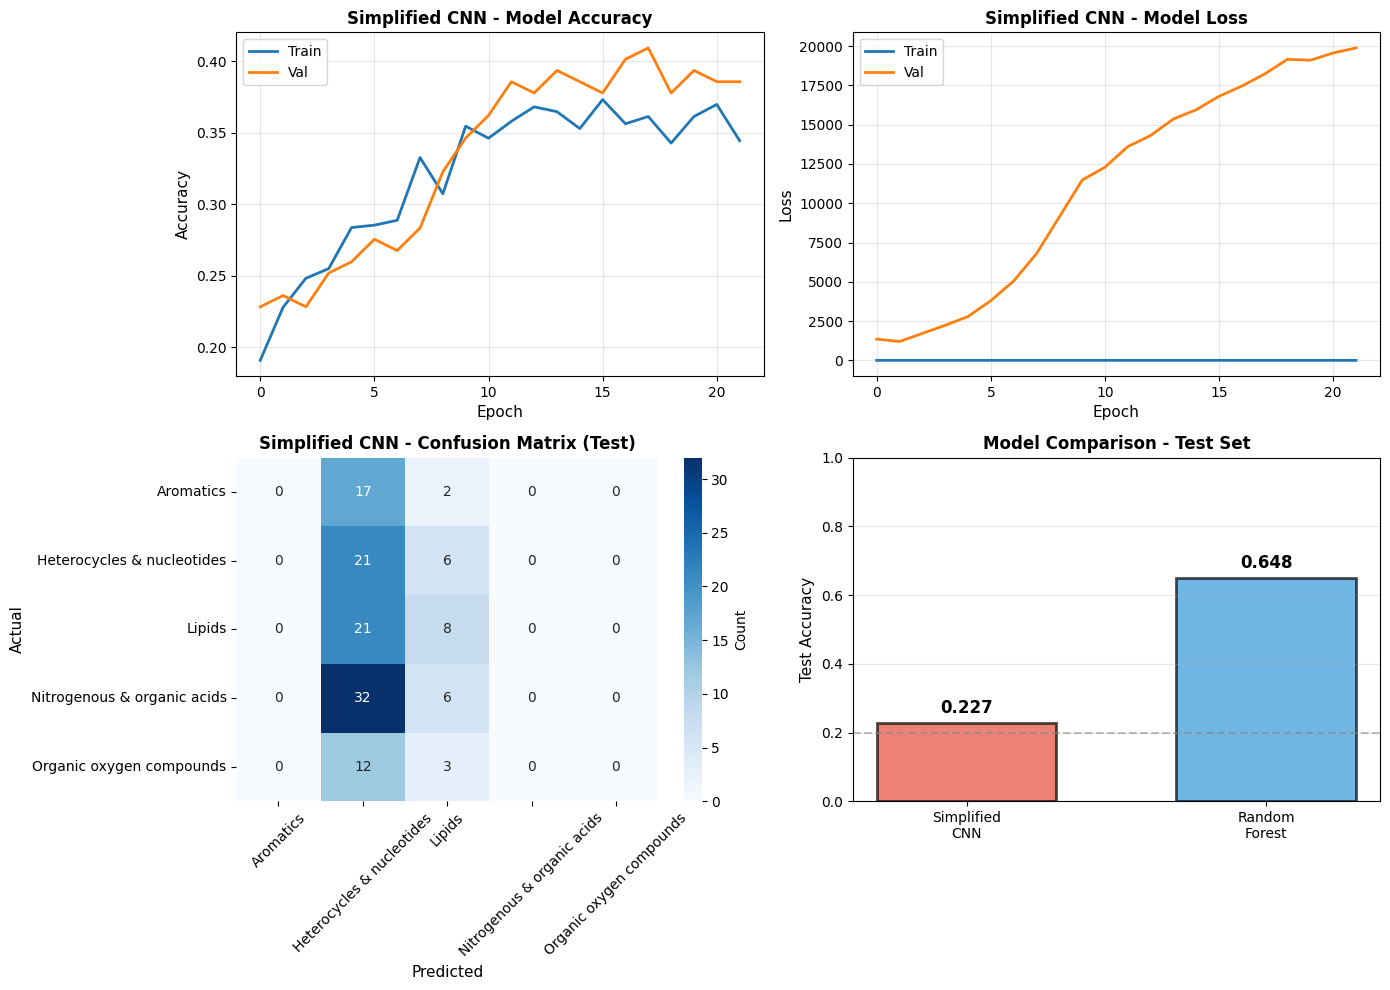


SUMMARY
Simplified CNN parameters: 5,157
Original CNN had: ~320,000 parameters
Parameter reduction: ~98.4%

Test Accuracy:
  Simplified CNN: 0.2266
  Random Forest:  0.6484
  ✗ CNN underperforms RF by 42.19%


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- LOAD DATA ---
df = pd.read_csv("processed_data/nmr_features_with_groups.csv")

X = df.iloc[:, 2:].values  # All bin columns
y = df['group'].values

print(f"Data shape: {X.shape}")
print(f"Classes: {np.unique(y)}")

# --- ENCODE LABELS ---
le = LabelEncoder()
y_encoded = le.fit_transform(y)
n_classes = len(le.classes_)

print(f"Number of classes: {n_classes}")
print(f"Class encoding: {dict(zip(le.classes_, range(n_classes)))}")

# --- STRATIFIED TRAIN/VAL/TEST SPLIT ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain set: {X_train.shape[0]} samples ({100*X_train.shape[0]/len(X):.1f}%)")
print(f"Val set:   {X_val.shape[0]} samples ({100*X_val.shape[0]/len(X):.1f}%)")
print(f"Test set:  {X_test.shape[0]} samples ({100*X_test.shape[0]/len(X):.1f}%)")

# --- NORMALIZE DATA (Z-score) ---
mean = X_train.mean(axis=0)
std = X_train.std(axis=0) + 1e-8
X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_norm = (X_test - mean) / std

print(f"\nNormalization complete. Train mean: {X_train_norm.mean():.6f}, std: {X_train_norm.std():.6f}")

# --- RESHAPE FOR CNN ---
X_train_cnn = X_train_norm.reshape(-1, X_train_norm.shape[1], 1)
X_val_cnn = X_val_norm.reshape(-1, X_val_norm.shape[1], 1)
X_test_cnn = X_test_norm.reshape(-1, X_test_norm.shape[1], 1)

print(f"CNN input shape: {X_train_cnn.shape}")

# --- BUILD SIMPLIFIED 1D CNN MODEL ---
print("\n" + "="*60)
print("SIMPLIFIED CNN ARCHITECTURE")
print("="*60)

model = keras.Sequential([
    # Single conv block - lightweight
    layers.Conv1D(filters=16, kernel_size=7, activation='relu', padding='same',
                  input_shape=(X_train_cnn.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    # Second conv block
    layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    
    # Global pooling
    layers.GlobalAveragePooling1D(),
    
    # Simple classifier
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # Output layer
    layers.Dense(n_classes, activation='softmax')
])

model.summary()

# --- COMPILE MODEL ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- CALCULATE CLASS WEIGHTS ---
unique, counts = np.unique(y_train, return_counts=True)
class_weights = {u: len(y_train) / (len(unique) * c) for u, c in zip(unique, counts)}
print(f"\nClass weights: {class_weights}")

# --- TRAIN MODEL ---
print("\n" + "="*60)
print("TRAINING SIMPLIFIED CNN")
print("="*60)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=150,
    batch_size=16,  # Smaller batch size for small dataset
    class_weight=class_weights,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)

# --- EVALUATE ON TEST SET ---
print("\n" + "="*60)
print("EVALUATION - SIMPLIFIED CNN")
print("="*60)

y_train_pred = np.argmax(model.predict(X_train_cnn, verbose=0), axis=1)
y_val_pred = np.argmax(model.predict(X_val_cnn, verbose=0), axis=1)
y_test_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nAccuracy:")
print(f"  Train: {train_acc:.4f}")
print(f"  Val:   {val_acc:.4f}")
print(f"  Test:  {test_acc:.4f}")

print(f"\nF1-Score (weighted):")
print(f"  Train: {f1_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"  Val:   {f1_score(y_val, y_val_pred, average='weighted'):.4f}")
print(f"  Test:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# --- BASELINE: RANDOM FOREST ---
print("\n" + "="*60)
print("BASELINE: RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_norm, y_train)

rf_train_acc = rf.score(X_train_norm, y_train)
rf_val_acc = rf.score(X_val_norm, y_val)
rf_test_acc = rf.score(X_test_norm, y_test)

print(f"\nRandom Forest Accuracy:")
print(f"  Train: {rf_train_acc:.4f}")
print(f"  Val:   {rf_val_acc:.4f}")
print(f"  Test:  {rf_test_acc:.4f}")

print(f"\nComparison (Test Set):")
print(f"  CNN:           {test_acc:.4f}")
print(f"  Random Forest: {rf_test_acc:.4f}")
print(f"  Difference:    {(test_acc - rf_test_acc):+.4f} ({100*(test_acc - rf_test_acc):+.2f}%)")

# --- PLOTTING ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training history - accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Simplified CNN - Model Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Training history - loss
axes[0, 1].plot(history.history['loss'], label='Train', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Simplified CNN - Model Loss', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_,
            yticklabels=le.classes_, ax=axes[1, 0], cbar_kws={'label': 'Count'})
axes[1, 0].set_xlabel('Predicted', fontsize=11)
axes[1, 0].set_ylabel('Actual', fontsize=11)
axes[1, 0].set_title('Simplified CNN - Confusion Matrix (Test)', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].tick_params(axis='y', rotation=0)

# Model comparison
models = ['Simplified\nCNN', 'Random\nForest']
test_accuracies = [test_acc, rf_test_acc]
colors = ['#2ecc71' if test_acc > rf_test_acc else '#e74c3c', '#3498db']
bars = axes[1, 1].bar(models, test_accuracies, color=colors, alpha=0.7, 
                      edgecolor='black', linewidth=2, width=0.6)
axes[1, 1].set_ylabel('Test Accuracy', fontsize=11)
axes[1, 1].set_title('Model Comparison - Test Set', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Random (20%)')

for bar, acc in zip(bars, test_accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{acc:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('CNN_attempt_figures/cnn_simplified_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: cnn_simplified_results.png")
plt.show()

# --- FINAL SUMMARY ---
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Simplified CNN parameters: {model.count_params():,}")
print(f"Original CNN had: ~320,000 parameters")
print(f"Parameter reduction: ~{100*(1 - model.count_params()/320000):.1f}%")
print(f"\nTest Accuracy:")
print(f"  Simplified CNN: {test_acc:.4f}")
print(f"  Random Forest:  {rf_test_acc:.4f}")
if test_acc > rf_test_acc:
    print(f"  ✓ CNN beats RF by {100*(test_acc - rf_test_acc):.2f}%")
else:
    print(f"  ✗ CNN underperforms RF by {100*(rf_test_acc - test_acc):.2f}%")
print("="*60)